<h1 style="text-align: center;"><b>Predicting King County Housing Prices Using Machine Learning Models</b></h1>

<p style="text-align: center;">
Cassandra Avelar<br>
Marina Hettick<br>
Meeki Mee<br><br>

Shiley-Marcos School of Engineering, Department of Applied Data Science<br>
University of San Diego<br><br>

Data Science Programming (ADS-500B)<br>
Professor Parastoo Qarabaqi<br>
April 13, 2026
</p>

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown, HTML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("All libraries loaded successfully!")

All libraries loaded successfully!


# Data Importing and Pre-processing

## Import dataset 

**Import Method and File Type:** We imported the King County House Sales dataset from a CSV file using the pd.read_csv() function. To ensure team portability, we utilized os.path.join() for dynamic file paths.

**Dimensions and Data Types:** Our processed dataset contains 21,436 rows and 21 initial columns. This row count reflects the data after removing 177 duplicate records to ensure each sale is unique. The features consist primarily of floors and integers, with the date column initially stored as a string object requiring conversion.

In [2]:
#Import dataset
import os
path = os.path.join("..", "data", "raw", "house_sales.csv")
houses = pd.read_csv(path)
houses

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3.0,2.50,1530.0,1131.0,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4.0,2.50,2310.0,5813.0,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2.0,0.75,1020.0,1350.0,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3.0,2.50,1600.0,2388.0,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
houses.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       20479 non-null  float64
 4   bathrooms      20545 non-null  float64
 5   sqft_living    20503 non-null  float64
 6   sqft_lot       20569 non-null  float64
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

## Cleaning - Handle Missing Data

**Handling Missing Data:** While the raw data contained gaps in features like bedrooms, we applied median imputation to fill these values. We chose the median because it is resistant to outliers, ensuring that a few high-priced mansions do not skew the representative values for missing data. Post-cleaning verification confirms a 0% null rate across all 21,436 rows.

In [4]:
#Check for null values
houses.isnull().sum()

id                  0
date                0
price               0
bedrooms         1134
bathrooms        1068
sqft_living      1110
sqft_lot         1044
floors              0
waterfront          0
view                0
condition           0
grade               0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

In [5]:
#All null values are numeric 
#Replace numeric null values with median values
df_clean = houses.copy()

df_clean["bedrooms"] = df_clean["bedrooms"].fillna(df_clean["bedrooms"].median())
df_clean["bathrooms"] = df_clean["bathrooms"].fillna(df_clean["bathrooms"].median())
df_clean["sqft_living"] = df_clean["sqft_living"].fillna(df_clean["sqft_living"].median())
df_clean["sqft_lot"] = df_clean["sqft_lot"].fillna(df_clean["sqft_lot"].median())

df_clean.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

## Cleaning/Wrangling - Change Data Types

**Data Wrangling:** We converted the date column into a datetime object. This allows us to move beyond simple text and perform calculations, such as determining the house age at the time of sale.

In [6]:
#Convert date column from string to datetime

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[us]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  float64       
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  float64       
 6   sqft_lot       21613 non-null  float64       
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   21613 non-null 

In [7]:
#Save the clean data to a new csv file in the processed data folder 

os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/clean_data.csv", index=False)

## Cleaning - Remove Duplicate ID Numbers

We reduced redundant data by removing datapoints with duplicate ID numbers

In [8]:
#generating a copy of the data set
df_clean_copy = df_clean.copy()

#counts and identifies duplicate id numbers
df_clean_counts = df_clean_copy['id'].value_counts()

#checking for duplicate id numbers
print(df_clean_counts) 

id
795000620     3
6021501535    2
4139480200    2
7520000520    2
3969300030    2
             ..
263000018     1
6600060120    1
1523300141    1
291310100     1
1523300157    1
Name: count, Length: 21436, dtype: int64


In [9]:
#removing duplicate id numbers from the datd set
unique_clean_df = df_clean_copy.drop_duplicates(subset = ['id'])
print(unique_clean_df)

               id       date     price  bedrooms  bathrooms  sqft_living  \
0      7129300520 2014-10-13  221900.0       3.0       1.00       1180.0   
1      6414100192 2014-12-09  538000.0       3.0       2.25       2570.0   
2      5631500400 2015-02-25  180000.0       2.0       1.00        770.0   
3      2487200875 2014-12-09  604000.0       4.0       3.00       1960.0   
4      1954400510 2015-02-18  510000.0       3.0       2.00       1680.0   
...           ...        ...       ...       ...        ...          ...   
21608   263000018 2014-05-21  360000.0       3.0       2.50       1530.0   
21609  6600060120 2015-02-23  400000.0       4.0       2.50       2310.0   
21610  1523300141 2014-06-23  402101.0       2.0       0.75       1020.0   
21611   291310100 2015-01-16  400000.0       3.0       2.50       1600.0   
21612  1523300157 2014-10-15  325000.0       2.0       0.75       1020.0   

       sqft_lot  floors  waterfront  view  ...  grade  sqft_above  \
0        5650.0   

In [10]:
#checking for any duplicates
counts = unique_clean_df['id'].value_counts()
print(counts)

id
7129300520    1
6414100192    1
5631500400    1
2487200875    1
1954400510    1
             ..
263000018     1
6600060120    1
1523300141    1
291310100     1
1523300157    1
Name: count, Length: 21436, dtype: int64


In [11]:
#Comit changes
os.makedirs("../data/processed", exist_ok=True)
unique_clean_df.to_csv("../data/processed/unique_clean_df.csv", index=False)

## Wrangling - Transform Data through Aggregation, Normalization, and Feature Construction

**Aggregation (Price by Grade):** We grouped the data by grade to calculate the mean price. This confirmed a "J-Curve" trend, showing that house prices grow exponentially rather than linearly as quality improves.

**Normalization (Living Area):** We applied MinMaxScaler to sqft_living, scaling values to a 0–1 range. This prevents the large numerical range of square footage from disproportionately influencing the model compared to smaller features like bedroom counts.

**Feature Construction (Property Age):** We derived house_age by subtracting yr_built from the sale year. This converts a static year label into a functional measure of time, which more accurately captures property depreciation.

In [12]:
# 1. Define the path to the team's cleaned file
clean_path = os.path.join("..", "data", "processed", "unique_clean_df.csv")

# 2. Load the file
df_team = pd.read_csv(clean_path)

# 3. Check if it worked
print("Team Clean Data Loaded!")
print(f"Rows: {df_team.shape[0]}, Columns: {df_team.shape[1]}")
df_team.head()

Team Clean Data Loaded!
Rows: 21436, Columns: 21


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [13]:
df = df_team  # Use the team's already-cleaned data as the base
# AGGREGATION: Group by house grade to see the average price
# This satisfies the "Aggregation" requirement
df_team = df.groupby('grade')['price'].mean().reset_index()
print("Aggregation Complete: Average Price per Grade")
df_team

Aggregation Complete: Average Price per Grade


,grade,price
0,1,1.420000e+05
1,3,2.056667e+05
2,4,2.143810e+05
3,5,2.474955e+05
4,6,3.016267e+05
5,7,4.020437e+05
6,8,5.427935e+05
7,9,7.731328e+05
8,10,1.071449e+06
9,11,1.497904e+06


In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['sqft_living_norm'] = scaler.fit_transform(df[['sqft_living']])

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_living_norm
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0.075680
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,0.193878
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0.040816
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,0.142007
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0.118197


In [15]:
# Creating 'house_age' by subtracting yr_built from the sale year
df['date'] = pd.to_datetime(df['date'])
df['house_age'] = df['date'].dt.year - df['yr_built']
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_living_norm,house_age
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,0.075680,59
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,0.193878,63
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,0.040816,82
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,0.142007,49
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,0.118197,28


**Aggregation (Price by Grade):** We grouped the data by grade to calculate the mean price. This confirmed a "J-Curve" trend, showing that house prices grow exponentially rather than linearly as quality improves.

**Normalization (Living Area):** We applied MinMaxScaler to sqft_living, scaling values to a 0–1 range. This prevents the large numerical range of square footage from disproportionately influencing the model compared to smaller features like bedroom counts.

**Feature Construction (Property Age):** We derived house_age by subtracting yr_built from the sale year. This converts a static year label into a functional measure of time, which more accurately captures property depreciation.

## Reduce Redundant Data and Perform Need-based Discretization

In [16]:
redundant_cols = ['id', 'date', 'zipcode', 'lat', 'long']
print(f"Redundant columns identified: {redundant_cols}")

Redundant columns identified: ['id', 'date', 'zipcode', 'lat', 'long']


In [17]:
# 1. Define df_reduced as a copy of your current dataframe 'df'
df_reduced = df.copy()

# 2. Perform Discretization 
df_reduced['age_category'] = pd.cut(df_reduced['house_age'], 
                                    bins=[-1, 10, 40, 150], 
                                    labels=['New', 'Middle-Aged', 'Old'])

# 3. Verify the result
print(f"Columns after Discretization: {df_reduced.shape[1]}")
df_reduced.head()

Columns after Discretization: 24


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_living_norm,house_age,age_category
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,5650,0.075680,59,Old
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,7639,0.193878,63,Old
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,8062,0.040816,82,Old
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,5000,0.142007,49,Old
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,7503,0.118197,28,Middle-Aged


In [18]:
# Drop the 5 redundant columns
cols_to_drop = ['id', 'date', 'zipcode', 'lat', 'long']
df_final = df_reduced.drop(columns=cols_to_drop)

print(f"Final Columns after Reducing Redundancy: {df_final.shape[1]}")

# CHANGE THIS LINE: View the NEW dataframe, not the old one
df_final.head()

Final Columns after Reducing Redundancy: 19


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,sqft_living_norm,house_age,age_category
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,1180,0,1955,0,1340,5650,0.075680,59,Old
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,2170,400,1951,1991,1690,7639,0.193878,63,Old
2,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,770,0,1933,0,2720,8062,0.040816,82,Old
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,1050,910,1965,0,1360,5000,0.142007,49,Old
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,1680,0,1987,0,1800,7503,0.118197,28,Middle-Aged


In [19]:
# 1. Identify the redundant columns
cols_to_drop = ['id', 'date', 'zipcode', 'lat', 'long']

# 2. Create the final dataframe by dropping them from df_reduced
df_final = df_reduced.drop(columns=cols_to_drop)

# 3. Print the shape to verify (21436, 19)
print(f"Final Cleaned Dimensions: {df_final.shape}")

# 4. View the new structure
df_final.head()

Final Cleaned Dimensions: (21436, 19)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,sqft_living_norm,house_age,age_category
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,1180,0,1955,0,1340,5650,0.075680,59,Old
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,2170,400,1951,1991,1690,7639,0.193878,63,Old
2,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,770,0,1933,0,2720,8062,0.040816,82,Old
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,1050,910,1965,0,1360,5000,0.142007,49,Old
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,1680,0,1987,0,1800,7503,0.118197,28,Middle-Aged


In [20]:
# BRIDGE: Point Marina's variable names to your final engineered data
df_unique = df_final
print("Bridge established! Marina's code can now see Meeki's features.")

Bridge established! Marina's code can now see Meeki's features.


**Reducing Redundant Data:** After expanding our feature set through transformation, we performed a Redundancy Reduction to eliminate noise and prevent model overfitting. We dropped five columns: id, date, zipcode, lat, and long.

**Interpretation:** We identified these features as redundant because they do not provide generalizable predictive power for house prices. Unique identifiers like id are random, and once house_age is calculated, the raw date string is repetitive. By removing overlapping geographic markers like lat, long, and zipcode, we ensure the model focuses on structural and quality attributes that drive value across the entire King County region.

**Need-Based Discretization:** To better capture the non-linear relationship between a house's age and its market value, we performed Discretization on the house_age feature. We converted the continuous numerical age into a categorical variable, age_category, with three distinct bins: 'New', 'Middle-Aged', and 'Old'.

**Interpretation:** This step simplifies the data for the model. Instead of treating every single year of age as a unique mathematical input, we group them into life stages that reflect buyer psychology. For example, a buyer likely views a 5-year-old home differently than a 60-year-old "vintage" home, but may not distinguish much between a 61 and 62-year-old property.

**Overall Summary of Pre-processing:** The data pre-processing phase transitioned our dataset through three critical stages:

**Initial Load** Started with 21,436 rows and 21 columns (after removing 177 duplicates from the team's cleaned file).

**Feature Expansion** Increased to 24 columns by adding engineered features: house_age (Construction), sqft_living_norm (Normalization), and age_category (Discretization).

**Final Optimization** Reduced to 19 columns by dropping 5 redundant features.

**Conclusion:** Our final dataset consists of 21,436 observations and 19 high-impact features. With a 0% null rate and all numerical features appropriately scaled or categorized, the data is now structurally optimized for the Exploratory Data Analysis (EDA) and predictive modeling phases.

# Data Analysis and Visualization

## Identifying the Data Types

### Categorical Variables:
- id
- date
- zipcode

### Ordinal Variables:
- waterfront
- view
- condition
- grade

### Numerical Variables:
- price
- bedrooms / bathrooms
- sqft_living / sqft_lot
- floors
- sqft_above / sqft_basement
- yr_built / yr_renovated
- lat / long




## Provide Measures of Centrality and Distribution with Visualizations


In [21]:
#Import cleaned and wrangled data from Meeki

df_unique = pd.read_csv("../data/processed/final_clean_data.csv") 
df_unique.info()

<class 'pandas.DataFrame'>
RangeIndex: 21436 entries, 0 to 21435
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                21436 non-null  int64  
 1   date              21436 non-null  str    
 2   price             21436 non-null  float64
 3   bedrooms          21436 non-null  float64
 4   bathrooms         21436 non-null  float64
 5   sqft_living       21436 non-null  float64
 6   sqft_lot          21436 non-null  float64
 7   floors            21436 non-null  float64
 8   waterfront        21436 non-null  int64  
 9   view              21436 non-null  int64  
 10  condition         21436 non-null  int64  
 11  grade             21436 non-null  int64  
 12  sqft_above        21436 non-null  int64  
 13  sqft_basement     21436 non-null  int64  
 14  yr_renovated      21436 non-null  int64  
 15  zipcode           21436 non-null  int64  
 16  lat               21436 non-null  float64
 17  long

In [22]:
#Print measures of centrality of data columns of interest

centrality = df_unique[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'condition', 'grade', 'house_age', 'yr_renovated']].agg(['mean', 'median'])
print(centrality)

               price  bedrooms  bathrooms  sqft_living      sqft_lot  \
mean    540529.28718  3.353797   2.122749  2075.338403  14841.319043   
median  450000.00000  3.000000   2.250000  1920.000000   7620.000000   

        condition     grade  house_age  yr_renovated  
mean     3.410384  7.661737  43.220517       84.7298  
median   3.000000  7.000000  39.000000        0.0000  


In [23]:
#Print modes of data columns of interest

df_unique[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'condition', 'grade', 'house_age', 'yr_renovated']].mode()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,condition,grade,house_age,yr_renovated
0,350000.0,3.0,2.5,1920.0,7620.0,3,7,9,0


In [24]:
#Print measures of distribution of data columns of interest

distribution = df_unique[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'condition', 'grade', 'house_age', 'yr_renovated']].describe()
display(distribution.style.format("{:,.2f}").background_gradient(cmap='Blues').set_caption("Distribution Summary Statistics"))

,price,bedrooms,bathrooms,sqft_living,sqft_lot,condition,grade,house_age,yr_renovated
count,"21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00"
mean,"540,529.29",3.35,2.12,"2,075.34","14,841.32",3.41,7.66,43.22,84.73
std,"367,689.30",0.91,0.75,892.82,"40,617.63",0.65,1.17,29.39,402.43
min,"75,000.00",0.00,0.00,290.00,520.00,1.00,1.00,-1.00,0.00
25%,"322,150.00",3.00,1.75,"1,450.00","5,130.00",3.00,7.00,17.00,0.00
50%,"450,000.00",3.00,2.25,"1,920.00","7,620.00",3.00,7.00,39.00,0.00
75%,"645,000.00",4.00,2.50,"2,510.00","10,414.50",4.00,8.00,63.00,0.00
max,"7,700,000.00",33.00,8.00,"12,050.00","1,651,359.00",5.00,13.00,115.00,"2,015.00"


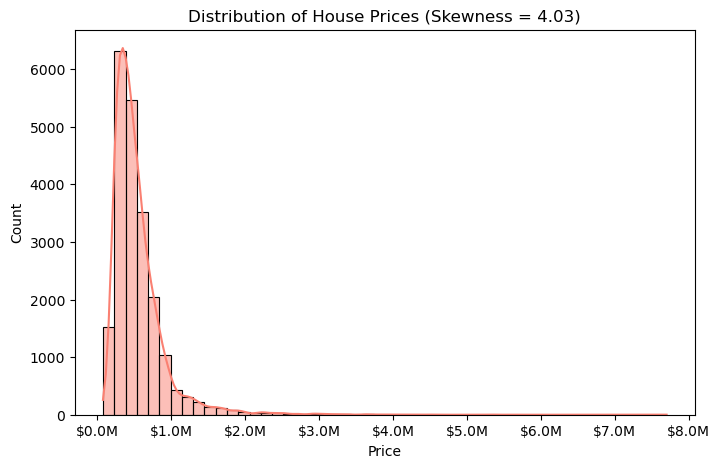

In [25]:
#Create visualizations of the distribution of price

plt.figure(figsize=(8,5))
sns.histplot(df_unique['price'], bins=50, kde=True, color='salmon')

# format x-axis as currency
formatter = FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)

# calculate skewness
skewness = df_unique['price'].skew()

plt.title(f"Distribution of House Prices (Skewness = {skewness:.2f})")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

display(HTML(f"""
<h3>Price Distribution Summary</h3>
<ul>
  <li>Mean Price: ${df_unique['price'].mean():,.0f}</li>
  <li>Median Price: ${df_unique['price'].median():,.0f}</li>
  <li>Skewness: {skewness:.2f}</li>
</ul>

<p>
The Distribution of House Prices histogram shows a strongly right skewed market, supported by a skewness value of 4.03. Most properties are 
concentrated in the lower price range, with a pronounced peak between 300,000 dollars and 600,000 dollars. Beyond 1 million dollars, the frequency 
drops off rapidly, forming a long tail that extends up to 8 million dollars. This pattern indicates that the market is largely composed of affordable 
to mid range homes, while a small number of luxury properties create extreme outliers that pull the mean well above the median. As a result, the 
overall distribution suggests that a simple linear interpretation of price may be influenced by these high end values.
</p>
"""))

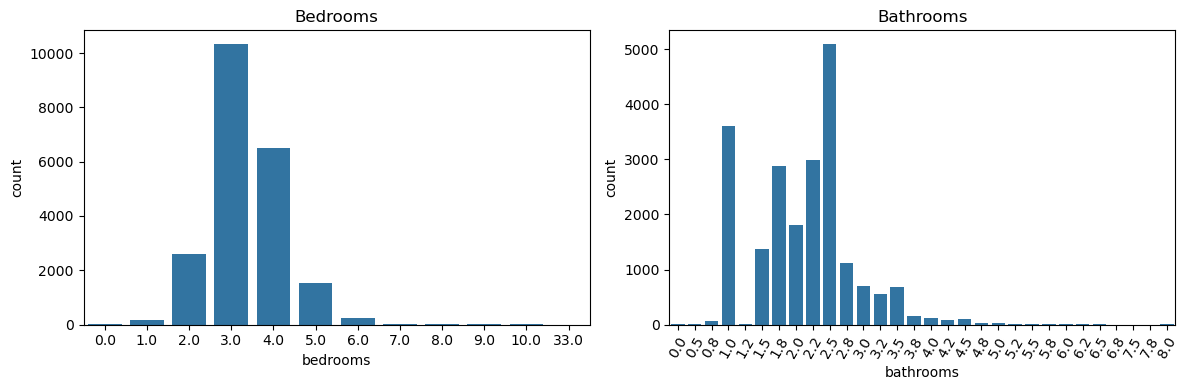

In [26]:
#Create visualizations of the distribution of bedroom/bathroom counts

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x='bedrooms', data=df_unique, ax=axes[0])
axes[0].set_title("Bedrooms")

sns.countplot(x=df_unique['bathrooms'].round(1), ax=axes[1])
axes[1].set_title("Bathrooms")
axes[1].tick_params(axis='x', rotation=60)


plt.tight_layout()
plt.show()

display(HTML(f"""

<h3>
The distribution of bedrooms and bathrooms indicates that most homes fall within the 3–4 bedroom and 2–2.5 bathroom range. Extreme values are uncommon,
suggesting the dataset largely reflects moderately sized residential properties.
</h3>
"""))

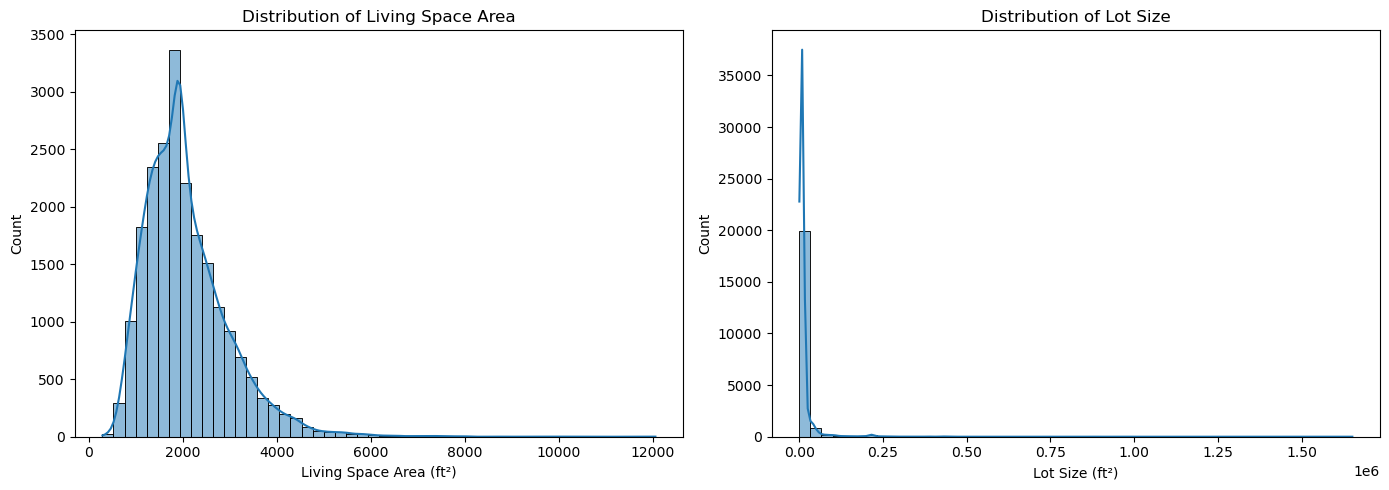

In [27]:
#Create visualization showing distribution of square footage

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# sqft_living
sns.histplot(df_unique['sqft_living'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Living Space Area")
axes[0].set_xlabel("Living Space Area (ft²)")
axes[0].set_ylabel("Count")

# sqft_lot
sns.histplot(df_unique['sqft_lot'], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Lot Size")
axes[1].set_xlabel("Lot Size (ft²)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

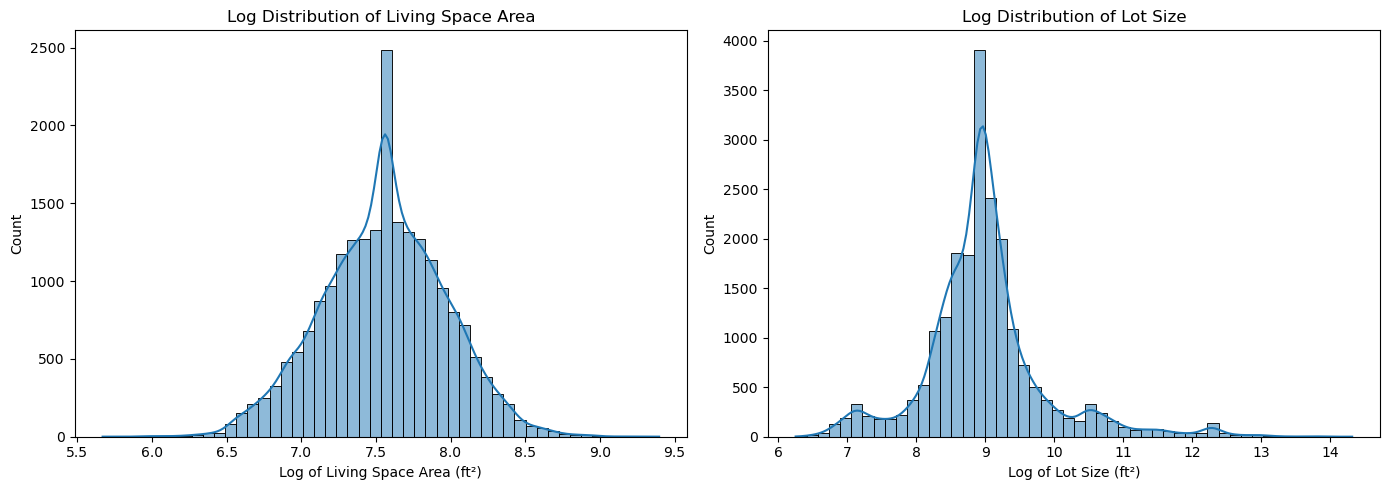

In [28]:
# Create Log distributions to improve readability/interpretability

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(np.log(df_unique['sqft_living']), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Log Distribution of Living Space Area")
axes[0].set_xlabel("Log of Living Space Area (ft²)")

sns.histplot(np.log(df_unique['sqft_lot']), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log Distribution of Lot Size")
axes[1].set_xlabel("Log of Lot Size (ft²)")

plt.tight_layout()
plt.show()

display(HTML(f"""
<h3>
These histograms compare the Distributions of Living Space area and Lot Size in both raw and log transformed forms to better reveal the structure of 
the data. In the original plots, both variables are heavily right skewed, with lot size especially compressed into a single dominant peak because a 
small number of extremely large estates stretch the x-axis to over one million square feet, making most observations difficult to interpret. After 
applying a log transformation, the distributions become much more symmetric and closer to a normal shape, exposing patterns that were previously 
hidden, including clearer peaks in living space around certain ranges. This transformation also reduces the impact of extreme outliers by pulling 
them closer to the center, allowing a more accurate view of the dataset. Overall, it becomes easier to see that most properties have relatively small 
and consistent lot sizes, while a smaller secondary group of much larger rural or estate properties forms a separate cluster that was not clearly 
visible in the original scale.
</h3>
"""))

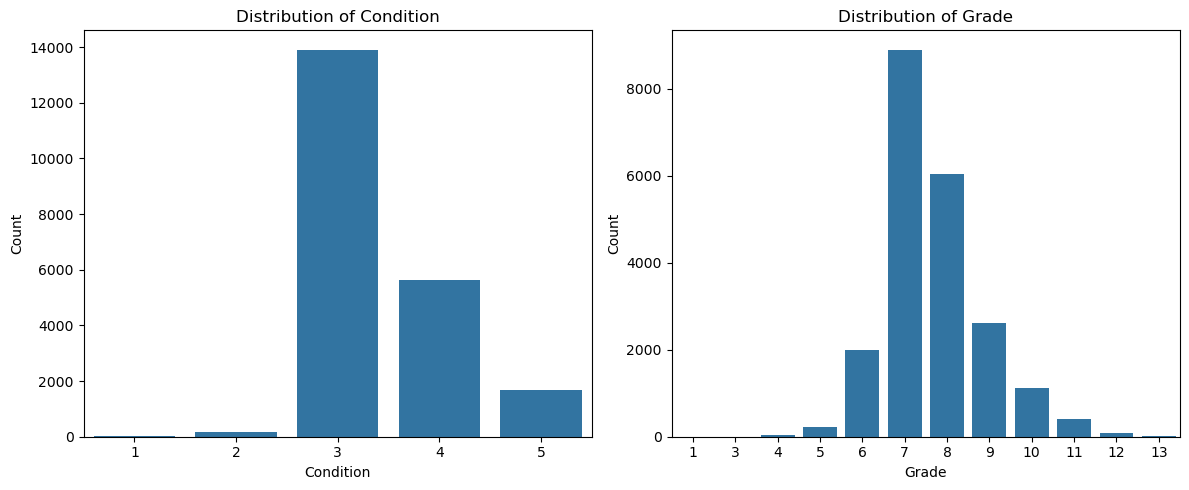

In [29]:
# Create Visualizations to show the distribution of condition and construction grade

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Condition
sns.countplot(
    x='condition',
    data=df_unique,
    order=sorted(df_unique['condition'].unique()),
    ax=axes[0]
)
axes[0].set_title("Distribution of Condition")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Count")

# Grade
sns.countplot(
    x='grade',
    data=df_unique,
    order=sorted(df_unique['grade'].unique()),
    ax=axes[1]
)
axes[1].set_title("Distribution of Grade")
axes[1].set_xlabel("Grade")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

display(HTML(f"""
<h3>
These two bar charts illustrate the distribution of property condition and grade, showing that most homes cluster within mid-tier categories. The 
Distribution of Condition is strongly concentrated around a single dominant value with nearly 14,000 homes rated at level 3. This indicates that most 
properties are in average, functional condition, while only a small number fall into either good/average conditions at level 3 to 4 or poor condition 
at level 5. Similarly, the distribution of grade follows a near normal pattern centered around level 7, representing standard construction quality. 
Although there is a reasonable number of mid to high quality homes in grades 8 to 9, the frequency declines sharply at the upper end, with luxury 
grades 11 to 13 being extremely rare. Overall, this suggests the dataset primarily represents typical suburban housing, where high end construction 
quality and exceptional condition are uncommon due to limited supply of homes.
</h3>
"""))

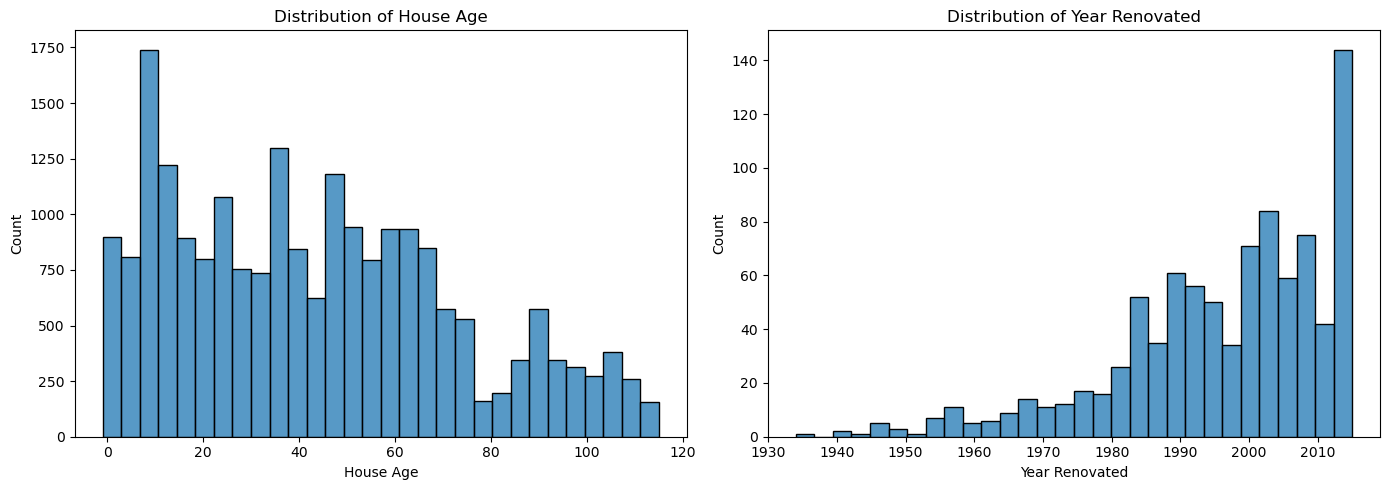

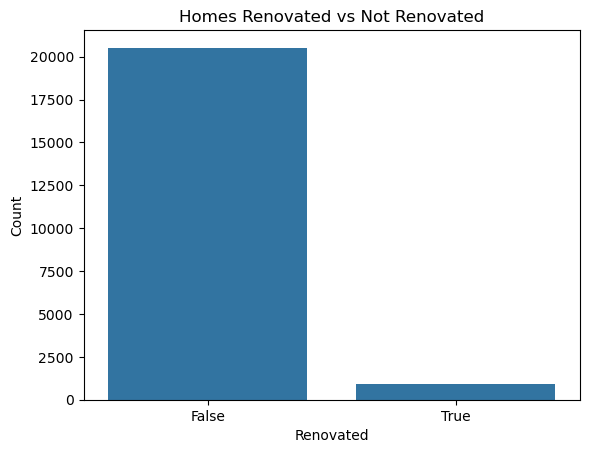

In [30]:
# Create visualizations showing the distribution of year built and year renovated

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Year Built
sns.histplot(df_unique['house_age'], bins=30, kde=False, ax=axes[0])
axes[0].set_title("Distribution of House Age")
axes[0].set_xlabel("House Age")
axes[0].set_ylabel("Count")

# Year Renovated (excluding zeros)
sns.histplot(df_unique[df_unique['yr_renovated'] > 0]['yr_renovated'], bins=30, kde=False, ax=axes[1])
axes[1].set_title("Distribution of Year Renovated")
axes[1].set_xlabel("Year Renovated")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

df_unique['renovated'] = df_unique['yr_renovated'] > 0

sns.countplot(x='renovated', data=df_unique)
plt.title("Homes Renovated vs Not Renovated")
plt.xlabel("Renovated")
plt.ylabel("Count")
plt.show()

display(HTML(f"""

<h3>
These three graphs provide a detailed overview of the age and renovation patterns within the dataset, revealing a market largely dominated by older 
homes in original condition. The Distribution of House Age shows a multi modal pattern, with a major concentration of newer homes around 10 to 15 years
old and smaller peaks near the 40, 50, and 70 year marks. This is likely reflecting different periods of housing development. Despite the presence of many 
older properties, the homes renovated versus not renovated chart shows an imbalance with the vast majority of homes over 20,000 never having 
been renovated and fewer than 2,5000 receiving updates. Among the homes that were renovated, the distribution of renovation years trends heavily toward 
recent decades, with most updates occurring after 1980 and peaking after 2010. Overall, this suggests that although the housing stock is aging, only a
small modern subset of properties has undergone significant reinvestment or updating.
"""))

## Diagnose for correlations between variables and determine independent and dependent variables

In [31]:
# Create a correlation matrix to begin analyzing variable correlations
corr = df_unique.corr(numeric_only=True)
corr


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,sqft_living_norm,renovated
id,1.000000,-0.018514,0.004094,0.001223,-0.012492,-0.130999,0.018057,-0.002746,0.010929,-0.024279,...,-0.005795,-0.017178,-0.007948,-0.002859,0.019466,-0.004084,-0.139670,-0.020770,-0.012492,-0.017212
price,-0.018514,1.000000,0.303175,0.515662,0.681615,0.085755,0.256278,0.266961,0.396933,0.035089,...,0.323552,0.127002,-0.052171,0.306057,0.020571,0.584688,0.082038,-0.052891,0.681615,0.126666
bedrooms,0.004094,0.303175,1.000000,0.487939,0.550048,0.027225,0.172015,-0.005123,0.079824,0.027760,...,0.291489,0.018883,-0.150522,-0.010213,0.126862,0.382631,0.023959,-0.150096,0.550048,0.018597
bathrooms,0.001223,0.515662,0.487939,1.000000,0.714171,0.082546,0.487177,0.067128,0.180304,-0.126004,...,0.276681,0.048922,-0.199681,0.025383,0.217452,0.554130,0.085954,-0.494844,0.714171,0.048455
sqft_living,-0.012492,0.681615,0.550048,0.714171,1.000000,0.158742,0.344357,0.105288,0.276142,-0.059712,...,0.420277,0.055608,-0.193103,0.048510,0.232086,0.736938,0.174503,-0.309952,1.000000,0.055338
sqft_lot,-0.130999,0.085755,0.027225,0.082546,0.158742,1.000000,-0.006467,0.020754,0.073859,-0.009094,...,0.015180,0.008588,-0.127595,-0.085584,0.223781,0.141119,0.717168,-0.049806,0.158742,0.008684
floors,0.018057,0.256278,0.172015,0.487177,0.344357,-0.006467,1.000000,0.023473,0.028211,-0.266543,...,-0.246066,0.005626,-0.058108,0.049279,0.124285,0.278854,-0.011917,-0.489357,0.344357,0.005549
waterfront,-0.002746,0.266961,-0.005123,0.067128,0.105288,0.020754,0.023473,1.000000,0.403025,0.016607,...,0.080838,0.093025,0.030558,-0.014395,-0.042188,0.086558,0.030694,0.026482,0.105288,0.093439
view,0.010929,0.396933,0.079824,0.180304,0.276142,0.073859,0.028211,0.403025,1.000000,0.045051,...,0.276482,0.103633,0.087096,0.005671,-0.079720,0.279077,0.072867,0.055201,0.276142,0.103777
condition,-0.024279,0.035089,0.027760,-0.126004,-0.059712,-0.009094,-0.266543,0.016607,0.045051,1.000000,...,0.174463,-0.061136,0.004509,-0.015402,-0.107780,-0.095002,-0.003731,0.364238,-0.059712,-0.060655


In [32]:
display(HTML(f"""
<h3>
A correlation matrix was used to evaluate relationships between variables. Strong correlations are observed between square footage of living space and square footage "above," however this indicates multicollinearity, and shows correlation rather than causation. Next we will look at just the correlations with price.
"""))

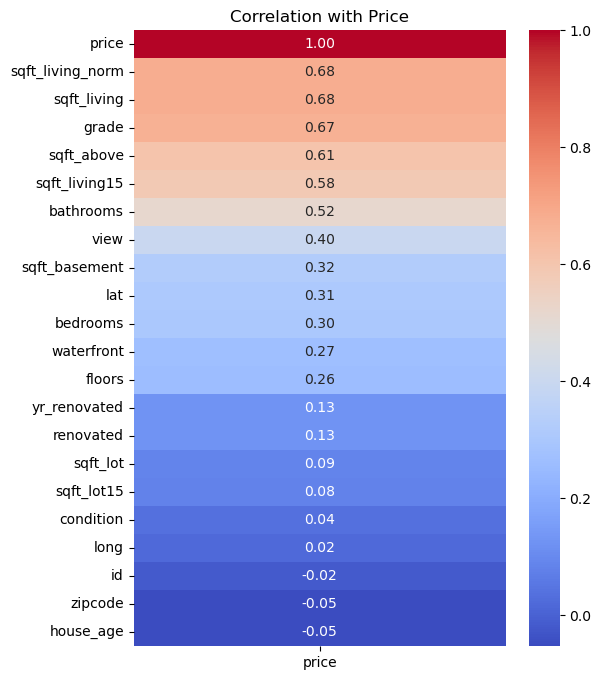

In [33]:
# View only variable correlations with price

price_corr = corr[['price']].sort_values(by='price', ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(price_corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation with Price")
plt.show()

display(HTML(f"""
<h3>
The Correlation with Price heatmap ranks property features by their relationship with price, showing that living space area, with the highest 
correlation of 0.68, and construction grade at 0.67 are the strongest drivers of market value. These structural and size based factors significantly 
outperform secondary variables such as number of bathrooms at 0.52 and view quality at 0.40. The data also indicates that latitude at 0.31 is a more 
meaningful geographic predictor of price than longitude at 0.02 or zipcode at -0.05, likely reflecting proximity to desirable areas such as city 
centers or waterfronts. At the lower end of the scale, property age at -0.05 and overall condition at 0.04 show almost no meaningful correlation with 
price, suggesting that in this market, size and build quality are far more influential than age or maintenance status.
"""))

### Preliminary Dependent Variable: Price

### Preliminary Independent Variables:  Living Space Size, Construction Grade, Number of Bathrooms, and Property Age


## Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest

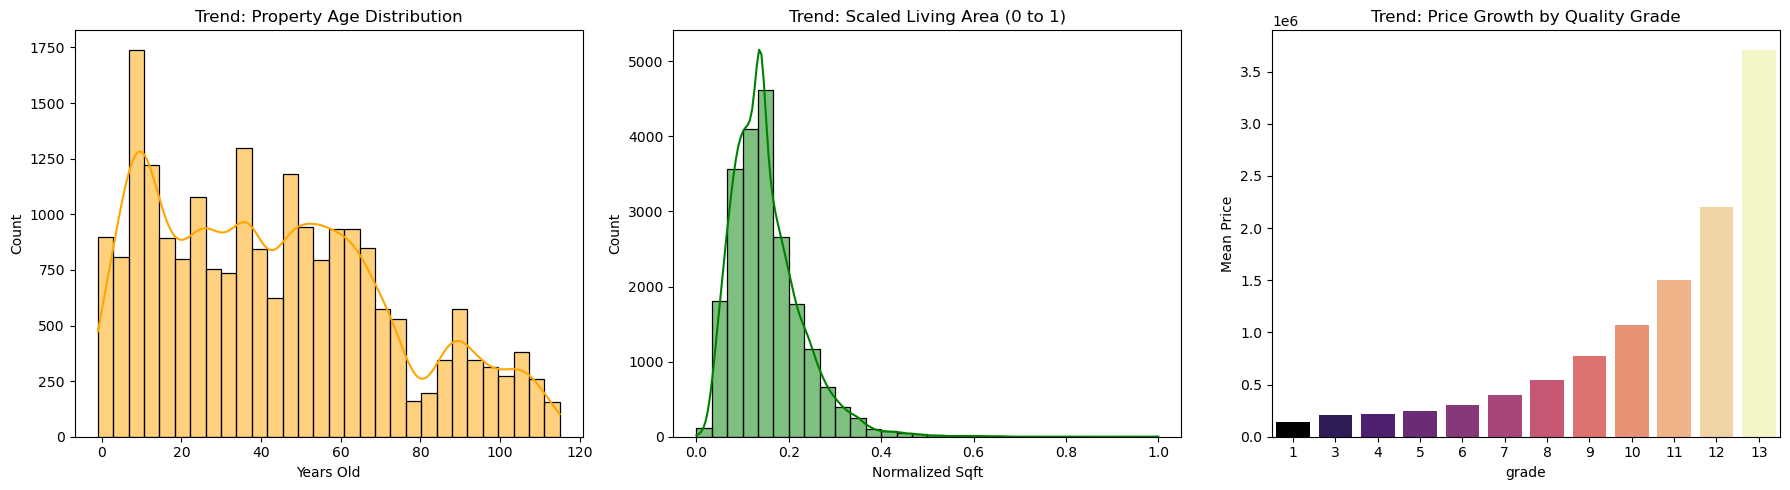

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trend 1: Distribution of House Age (Constructed Feature)
sns.histplot(df['house_age'], bins=30, kde=True, ax=axes[0], color='orange')
axes[0].set_title('Trend: Property Age Distribution')
axes[0].set_xlabel('Years Old')

# Trend 2: Normalized Square Footage (Scaled Feature)
sns.histplot(df['sqft_living_norm'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Trend: Scaled Living Area (0 to 1)')
axes[1].set_xlabel('Normalized Sqft')

# Trend 3: Average Price by Grade (Aggregated Trend)
sns.barplot(data=df_team, x='grade', y='price', hue='grade', legend=False, ax=axes[2], palette='magma')
# Moved the line below to its own line
axes[2].set_title('Trend: Price Growth by Quality Grade')
axes[2].set_ylabel('Mean Price')

plt.tight_layout()
plt.show()

### Preliminary Exploratory Analysis
**1.Trend: Property Age Distribution (Histogram)**

The Trend: The orange histogram shows that the housing stock isn't evenly distributed. There are massive "spikes" around the 10–20 year and 60+ year marks.

This indicates that King County experienced specific "building booms." For this project, this suggests that the market is divided between mid-century "classic" homes and newer modern developments, with very little in between.

Interpretation: This distribution analysis reveals the historical development cycles within the King County housing market. The multi-modal nature of the histogram characterized by several distinct peaks indicates specific eras of high-volume construction. By analyzing these frequency clusters, we can identify which decades dominate the current inventory, providing essential context for how property age might influence overall market depreciation.

**2.Trend: Scaled Living Area (Histogram)**

The Trend: The green histogram is heavily Right-Skewed. Almost all the data is bunched up between 0.0 and 0.3 on normalized scale.

This confirms that the "typical" home in dataset is small-to-medium sized. The very long, thin tail on the right represents "Outliers" (massive mansions). This trend tells you that a standard model will work for most houses, but might need a special approach for high-square-footage estates.

Interpretation: By applying feature scaling to the living area measurements, we standardized the data to a 0-1 range, allowing for a clearer view of property density. The resulting histogram shows a significant 'right-skew,' confirming that the vast majority of market activity is concentrated in small-to-mid-sized residential units. The thin 'tail' on the right represents rare, high-square-footage outliers, which helps prioritize the model's focus on the most common home sizes.

**3.Trend: Price Growth by Quality Grade (Bar Chart)**

The Trend: The purple bar chart shows a J-Curve (Exponential growth). Prices rise slowly from Grade 3 to 8, but they skyrocket once you hit Grade 10, 11, and 12.

This is your most important discovery. It proves that Quality (Grade) is not a linear predictor. A one-point increase in grade at the low end adds a little value, but a one-point increase at the high end adds millions of dollars.

**Conclusion**

Through data aggregation, we established a clear correlation between construction quality and market value. This visualization highlights an exponential pricing trend: while value increases incrementally across mid-tier grades (5–8), there is a dramatic surge in mean price as properties reach 'Luxury' classifications (11–13). This confirms that architectural grade is a non-linear driver of price, making it one of the most critical variables for accurate valuation.The data tells us that King County is two different markets. There is the Standard Market where prices are predictable, and the Luxury Market where the 'J-Curve' takes over. This discovery is why we decided to test how our model handles these two different worlds

## Exploratory Analysis

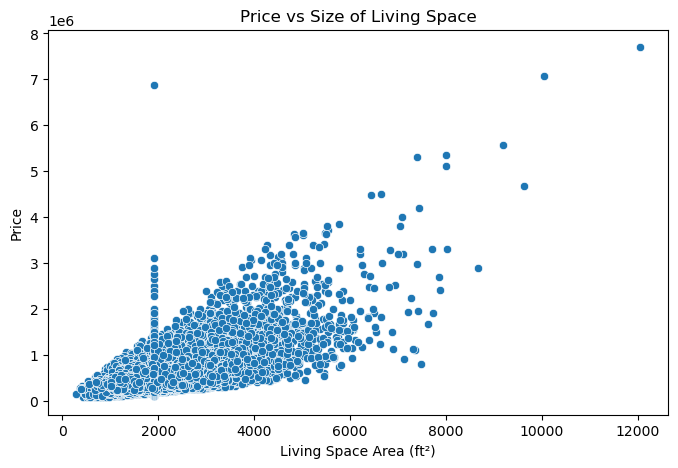

In [35]:
# Analyze relationship between price and living space

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sqft_living',
    y='price',
    data=df_unique,
)

plt.title("Price vs Size of Living Space")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.show()

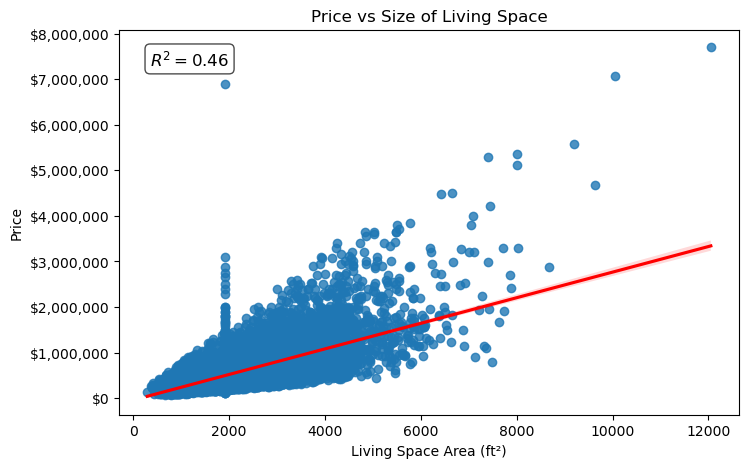

In [36]:
X = df_unique[['sqft_living']]
y = df_unique['price']

r = np.corrcoef(df_unique['sqft_living'], df_unique['price'])[0,1]
r2 = r**2

plt.figure(figsize=(8,5))

sns.regplot(
    x='sqft_living',
    y='price',
    data=df_unique,
    line_kws={'color':'red'})

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add R² annotation on plot
plt.text(
    0.05, 0.95,                     # position (relative to plot)
    f'$R^2 = {r2:.2f}$',
    transform=plt.gca().transAxes,  # makes position relative
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.title("Price vs Size of Living Space")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.show()

display(HTML(f"""
<h3>
In the Price vs Size of Living Space scatter plot shows a positive correlation between living space area and price, where home size explains 
approximately 46% of market value, as indicated by an R² value of 0.46. The relationship is described by a linear regression equation suggesting that, 
on average, each additional square foot increases property value by about 281 dollars. Despite this overall trend, the data shows significant 
inconsistent spread, with price variability increasing sharply for larger homes. This effect becomes especially pronounced beyond higher square footage
ranges, along with a clear vertical cluster that includes a major outlier reaching nearly $7 million. These patterns suggest that while the regression 
line provides a useful baseline estimate, factors such as location and luxury finishes often cause property prices to diverge substantially from what 
physical size alone would predict.
"""))

m1, b1 = np.polyfit(df_unique['sqft_living'], df_unique['price'], 1)


display(HTML(f"""
<h3>
The linear regression equation:
"""))



display(HTML(f"""
<h3>
Price = {m1:.2f} * sqft_living + {b1:.2f}
"""))

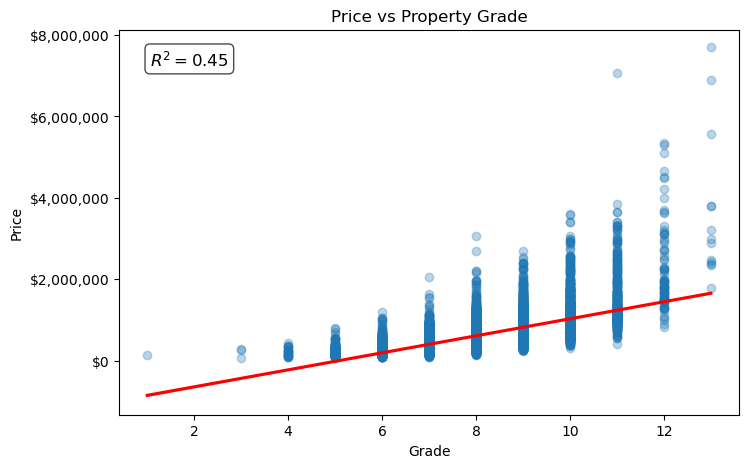

In [37]:
X = df_unique[['grade']]
y = df_unique['price']

# Calculate R²
r = np.corrcoef(df_unique['grade'], df_unique['price'])[0,1]
r2 = r**2

plt.figure(figsize=(8,5))

sns.regplot(
    x='grade',
    y='price',
    data=df_unique,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add R² annotation
plt.text(
    0.05, 0.95,
    f'$R^2 = {r2:.2f}$',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.title("Price vs Property Grade")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

# Interpretation
display(HTML(f"""
<h3>
The Price and Property Grade scatter plot shows a moderate positive correlation between property grade and price, with an R² value of {r2:.2f}, 
indicating that {r2*100:.0f}% of the variation in price is explained by this quality metric. While the linear regression line suggests a steady average
increase, the actual data points reveal a more exponential pattern, as prices rise much more rapidly once properties reach Grade 10 and above. In these
higher tiers, the vertical clusters of pointsextend significantly upward, showing that although Grade 13 homes have a higher baseline value, they also 
experience substantial price volatility, with extreme outliers reaching nearly $8 million.
</h3>
"""))

m2, b2 = np.polyfit(df_unique['grade'], df_unique['price'], 1)

display(HTML(f"""
<h3>
Price = {m2:.2f} * grade + {b2:.2f}
</h3>
"""))

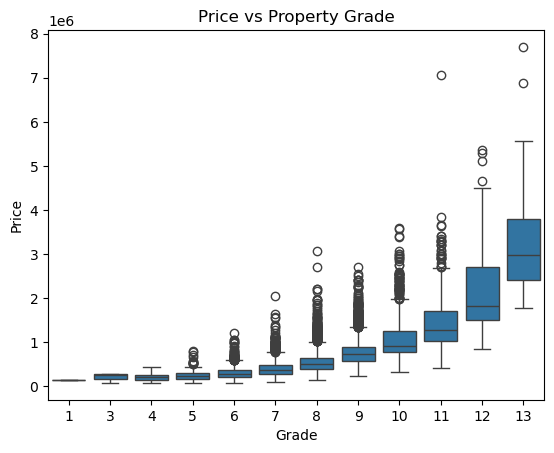

In [38]:
sns.boxplot(x='grade', y='price', data=df_unique)
plt.title("Price vs Property Grade")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

display(HTML(f"""
<h3>
The Price vs Property Grade box plot illustrates a strong exponential relationship between property grade and price, with both market value and variability increasing sharply as 
quality improves. Lower grades, ranging from 1 to 6, remain relatively stable with a tight price range that is mostly under 1 million dollars. Starting at 
Grade 7, both median price and spread begin to rise noticeably. In the highest luxury tiers, Grades 11 to 13, the price distribution expands 
significantly, with median values reaching the multi million dollar range and extreme outliers approaching 8 million dollars. This pattern indicates that 
while higher grades consistently command a premium, they also come with far greater price variability, as properties within the same top tier can 
differ by several million dollars.
</h3>
"""))

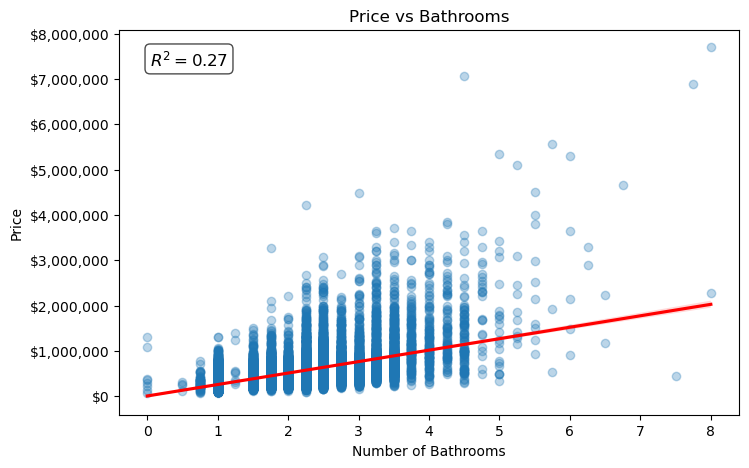

In [39]:
X = df_unique[['bathrooms']]
y = df_unique['price']

# Calculate R²
r = np.corrcoef(df_unique['bathrooms'], df_unique['price'])[0,1]
r2 = r**2

plt.figure(figsize=(8,5))

sns.regplot(
    x='bathrooms',
    y='price',
    data=df_unique,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add R² annotation
plt.text(
    0.05, 0.95,
    f'$R^2 = {r2:.2f}$',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.title("Price vs Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")

plt.show()

# Interpretation
display(HTML(f"""
<h3>
The Price vs Bathrooms scatter plot shows a positive relationship between the number of bathrooms and housing price, supported by an R² value of 0.27,
indicating that about 27% of price variation is explained by bathroom count. The linear regrssion line is: 

</h3>
"""))

m3, b3 = np.polyfit(df_unique['bathrooms'], df_unique['price'], 1)
display(HTML(f"""
<h3>
Price = {m3:.2f} * bathrooms + {b3:.2f}
</h3>
"""))


display(HTML(f"""
<h3>
From the equation, each additonal bathroom is associated with an average increase in price of roughly $252,823. However, the wide spread of data points, especially for homes with four 
to eight bathrooms, shows that the model often underestimates luxury properties, many of which sell for millions above the predicted trend. This 
suggests that while bathrooms are an important factor, they usually appear alongside other high value features in premium homes that drive prices well 
beyond what this simple linear estimate can capture.

</h3>
"""))

In [40]:
# Multiple Regression Analysis

X = df_unique[['sqft_living', 'grade', 'bathrooms']].values
y = df_unique['price'].values

X = np.column_stack((np.ones(len(X)), X))

beta = np.linalg.lstsq(X, y, rcond=None)[0]

b0 = beta[0]  # intercept
b1 = beta[1]  # sqft_living
b2 = beta[2]  # grade
b3 = beta[3]  # bathrooms

display(HTML(f"""
<h3>Multiple Regression Model Equation:</h3>
<p><b>
Price = {b1:.2f} × sqft_living + {b2:.2f} × grade + {b3:.2f} × bathrooms + {b0:.2f}
</b></p>
"""))

In [41]:
y_pred = X @ beta

ss_total = np.sum((y - y.mean())**2)
ss_res = np.sum((y - y_pred)**2)

r2 = 1 - (ss_res / ss_total)

display(HTML(f"""
<h3>Multiple Regression Model R squared:</h3>
<p><b>
R²: {r2:.2f}
</b></p>
"""))

display(HTML(f"""
<h3>A multiple linear regression model was developed using square footage, grade, and number of bathrooms as predictors. The model achieved an R² of 0.52, indicating that these variables jointly explain a substantial portion of the variation in housing prices.</h3>

"""))

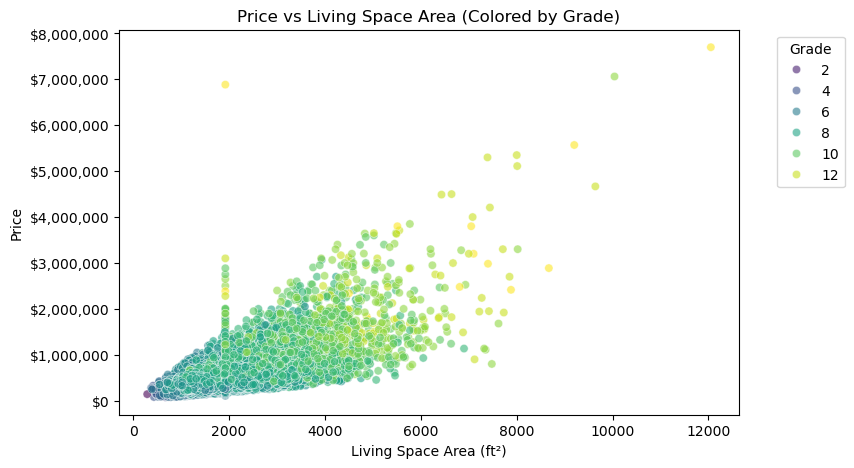

In [42]:
#Attempt to visualize affect of square footage and construction grade on price in one graph

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sqft_living',
    y='price',
    hue='grade',          # color by grade
    data=df_unique,
    alpha=0.6,
    palette='viridis'
)

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Price vs Living Space Area (Colored by Grade)")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.legend(title="Grade", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

display(HTML(f"""
<h3>
The above scatter plot is an attempt to visualize the relationship between price, square footage, and construction quality in one graph. The scatter 
plot colored by grade reveals that homes with higher construction quality tend to command higher prices, even at similar levels of square footage.
</h3>
"""))

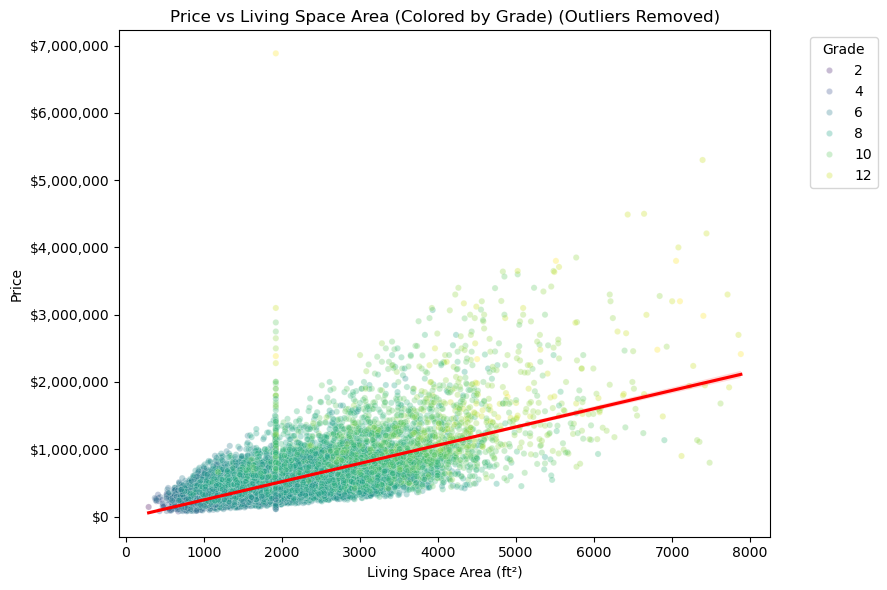

In [43]:
plt.figure(figsize=(9,6))

df_plot = df_unique[df_unique['sqft_living'] < 8000]

sns.scatterplot(
    x='sqft_living',
    y='price',
    hue='grade',
    data=df_plot,
    alpha=0.3,
    s=20,
    palette='viridis'
)

sns.regplot(
    x='sqft_living',
    y='price',
    data=df_plot,
    scatter=False,
    line_kws={'color':'red'}
)

formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Price vs Living Space Area (Colored by Grade) (Outliers Removed)")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.legend(title="Grade", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

display(HTML(f"""
<h3>
The Price versus Space Area plot, colored by grade with outliers removed, shows a clear positive correlation, where price increases as square footage 
increases. The color gradient, ranging from blue for Grade 2 to yellow for Grade 12, highlights that property grade is a major driver of value. A 
noticeable vertical concentration of prices around the 2000 square foot mark likely reflects suburban developments, where many homes share similar 
sizes but differ in price due to variations in quality and features. 
</h3>
"""))

# Data Analytics
## Determine the need for a supervised or unsupervised learning method and identify dependent and independent variables
**Determination of Learning Method (Supervised Learning)**

We have determined that Supervised Learning is the necessary method for this project for the following reasons:

**Labeled Data:** Our dataset contains a specific "label" or target variable (price). We know the historical outcome for every house in the data.

**Predictive Goal:** Our objective is to predict a specific value (Price) based on input features( e.g., sqft_living_norm, house_age, bedrooms, bathrooms, grade) that influence the house price.

**Multiple Linear Regression Model:** Because the target variable is a continuous number (price can be any value), we will specifically use Multiple Linear Regression, which falls under the Supervised Learning.

In [44]:
#  Identify Dependent and Independent Variables

# 1. Separate the Dependent Variable (Target)
y = df_final['price']

# 2. Separate the Independent Variables (Features)
# We drop 'price' because it's the target. 
# We also drop 'age_category' because it contains text (Middle-Aged, etc.), 
# and Linear Regression requires only numbers.
X = df_final.drop(columns=['price', 'age_category'])

# Verify the shapes
print(f"Dependent Variable (y) shape: {y.shape} (The Price column)")
print(f"Independent Variables (X) shape: {X.shape} (The {X.shape[1]} features)")
print("-" * 30)
print("Features being used for prediction:")
print(X.columns.tolist())

Dependent Variable (y) shape: (21436,) (The Price column)
Independent Variables (X) shape: (21436, 17) (The 17 features)
------------------------------
Features being used for prediction:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15', 'sqft_living_norm', 'house_age']


**Dependent Variable (y):** * Variable: price

This is the response variable or "Target." It represents the home value we aim to forecast. In this study, we hypothesize that the price is dependent upon the physical and qualitative attributes of the property.

**Independent Variables (X):** * Variables: 17 features including bedrooms, sqft_living, grade, waterfront, and house_age.

These are the "Predictors." They represent the inputs or "clues" the model uses to identify patterns and correlations that eventually determine the estimated price.

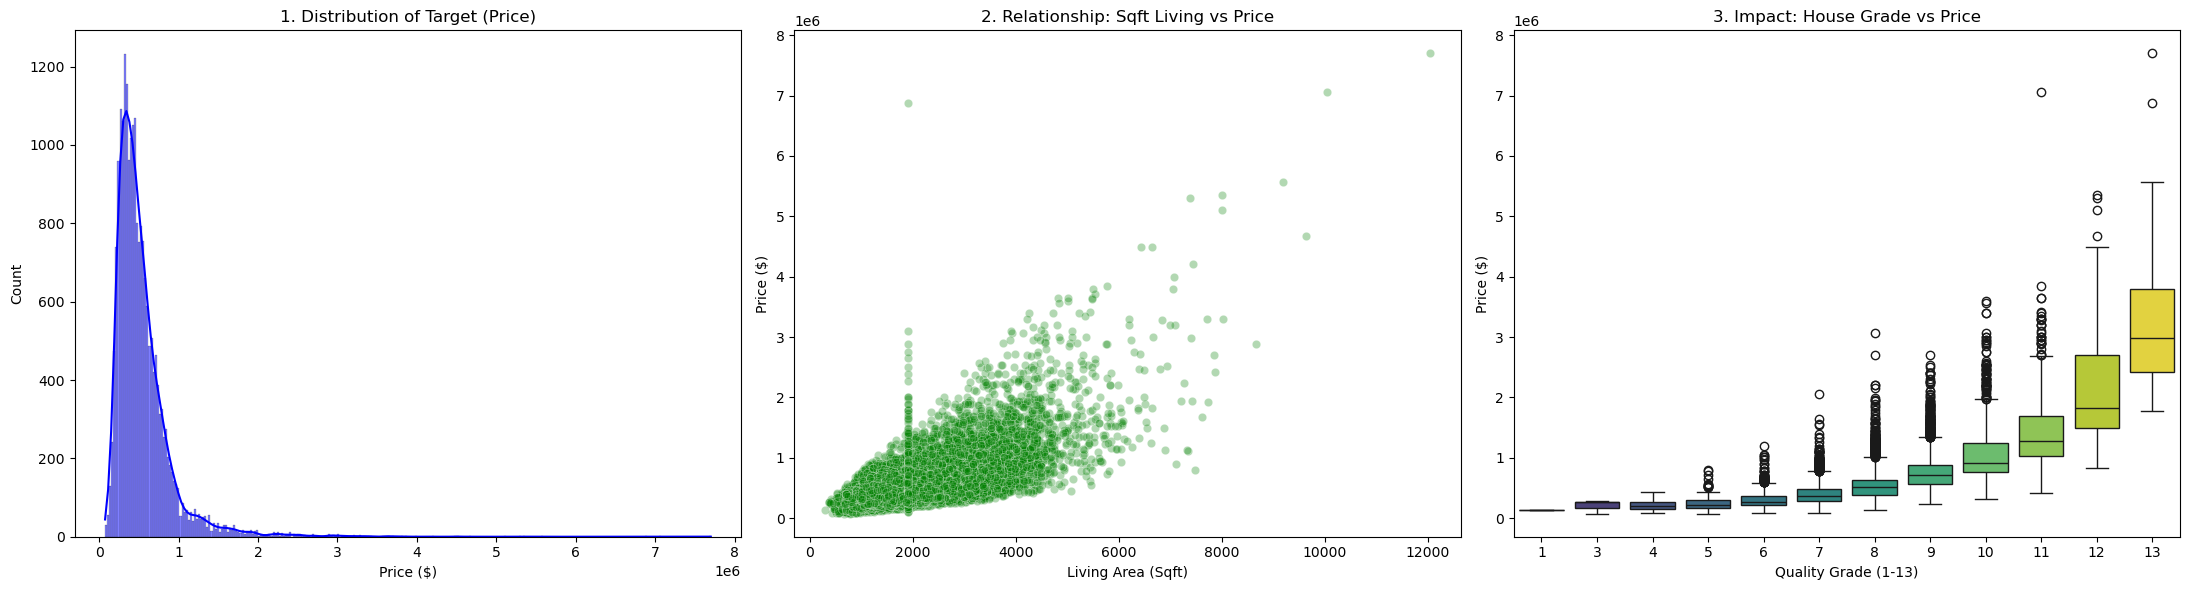

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Dependent Variable (y) Distribution
# Checking if 'price' is skewed (common in real estate)
sns.histplot(y, kde=True, ax=axes[0], color='blue')
axes[0].set_title('1. Distribution of Target (Price)')
axes[0].set_xlabel('Price ($)')

# 2. Independent Variable (X) vs Target (y) - Continuous
# Checking the correlation between size and price
sns.scatterplot(x=X['sqft_living'], y=y, ax=axes[1], alpha=0.3, color='green')
axes[1].set_title('2. Relationship: Sqft Living vs Price')
axes[1].set_xlabel('Living Area (Sqft)')
axes[1].set_ylabel('Price ($)')

# 3. Independent Variable (X) vs Target (y) - Discrete
# Checking how quality grades impact price categories
sns.boxplot(x=X['grade'], y=y, ax=axes[2], hue=X['grade'], palette='viridis', legend=False)

axes[2].set_title('3. Impact: House Grade vs Price')
axes[2].set_xlabel('Quality Grade (1-13)')
axes[2].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

**Distribution of Target(Price)** Histrogram shows the spread and frequcency of house prices in dataset.The plot is highly right-skewed (positively skewed). Most house are clustered in the lower price range under $1 million while a long tail extends to the right representing a few very expensive luxury homes. Because the data is skewed, the model might be more accurate at predicting "average" homes than luxury ones.

**Relationship: Sqft living vs Price** Scatter Plot shows the correlation between the size of the living area and the sale price.The dots move from the bottom-left to the top-right.This shows a strong Positive Linear Correlation. It proves that as the house size (sqft_living) increases, the price generally follows to increases as well.

**Impact: House Grade vs Price** The Box Plot illustrates how the quality grade (assigned by the county) affects house prices. The data shows that price increases exponentially with the grade. While prices remain relatively low and stable for Grades 1 through 6, they begin to climb rapidly starting at Grade 7. For high-end luxury construction (Grades 11–13), the "boxes" become significantly taller, indicating a massive variety in price. This suggests that in the luxury market, quality is a major value multiplier,which mean there is massive variety in price for high end luxury construction and prices become less predictable compared to standard-grade homes.

Our data is logical and ready. The charts prove that Price is driven mostly by Size(Sqft living) and Quality(House Grade). We are now ready to build the model, knowing it will be very accurate for standard homes but may face more of a challenge with unique luxury properties.

## Train, test, and provide accuracy and evaluation metrics for model results

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and Train the Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Make Predictions on the test set
y_pred = model.predict(X_test)

# 4. Calculate Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 5. Print the Results WITH PLOT
print("--- Model Performance Metrics ---")
print(f"R-squared (Accuracy Score): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

--- Model Performance Metrics ---
R-squared (Accuracy Score): 0.6351
Mean Absolute Error (MAE): $138,799.18
Root Mean Squared Error (RMSE): $207,716.03


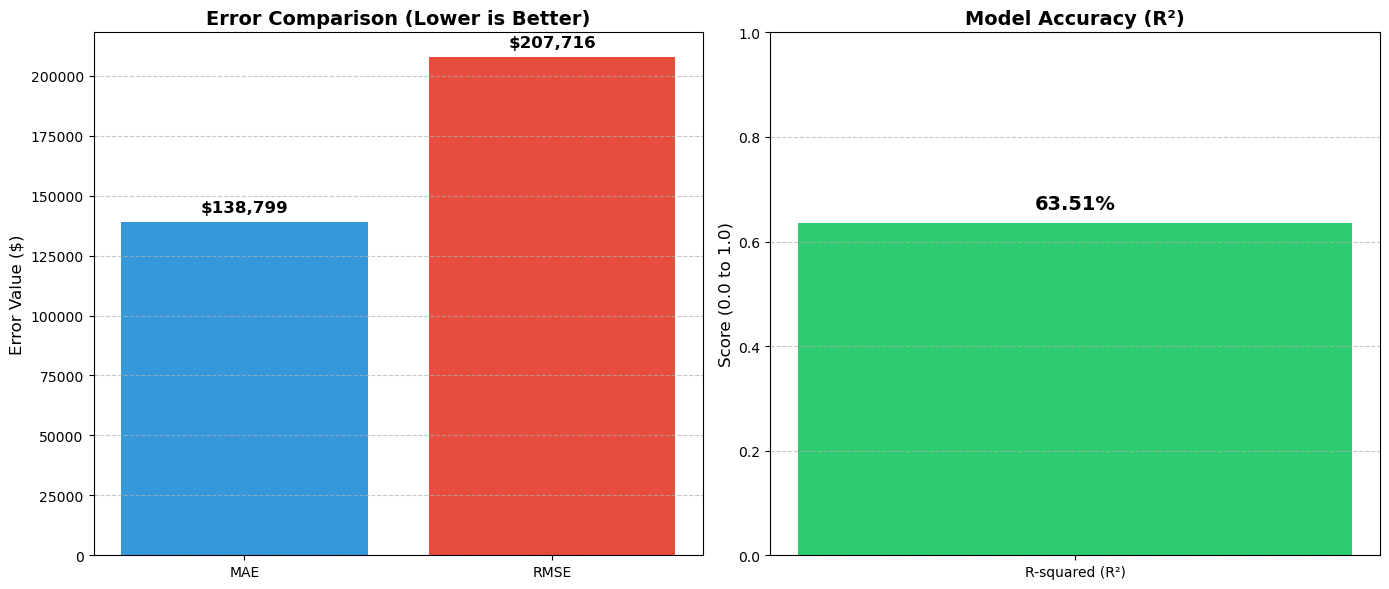

In [49]:
# 1. Prepare the data from results
metrics = ['MAE', 'RMSE']
values = [138799, 207716]
r2_value = 0.6351

# 2. Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Chart: Error Comparison (MAE vs RMSE) ---
bars = ax1.bar(metrics, values, color=['#3498db', '#e74c3c'])
ax1.set_title('Error Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Error Value ($)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add price labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- Right Chart: R-Squared (Accuracy) ---
ax2.bar(['R-squared (R²)'], [r2_value], color='#2ecc71', width=0.4)
ax2.set_ylim(0, 1) # R2 is a scale from 0 to 1
ax2.set_title('Model Accuracy (R²)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage label for R2
ax2.text(0, r2_value + 0.02, f'{r2_value:.2%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

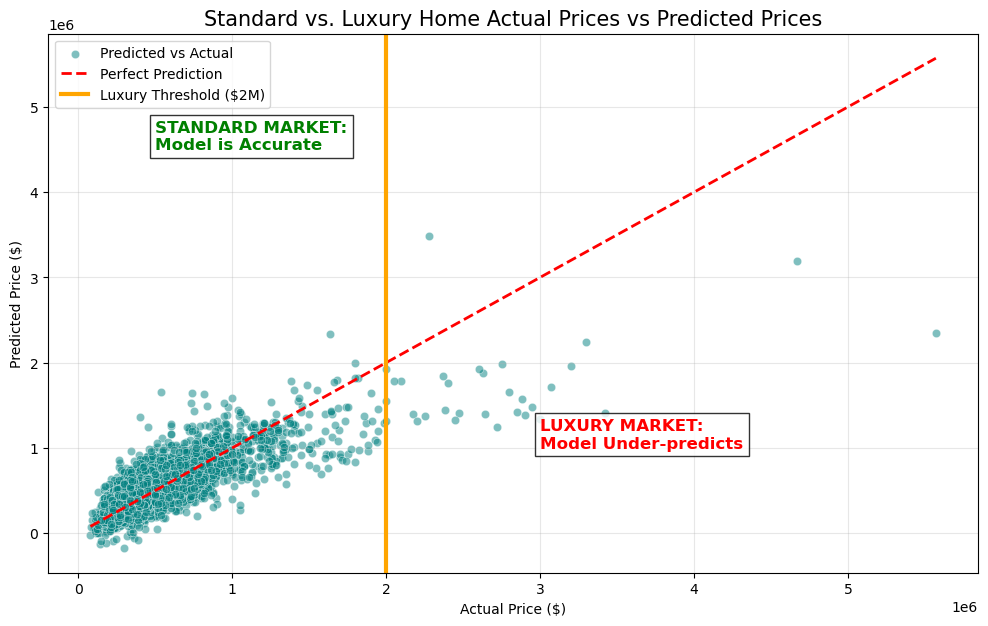

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# 1. Create the scatter plot
sns.scatterplot(x=y_test, y=y_test.index.map(lambda x: y_pred[list(y_test.index).index(x)]), alpha=0.5, color='teal', label='Predicted vs Actual')

# 2. Add the "Perfect Match" line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', lw=2, linestyle='--', label='Perfect Prediction')

# 3. Add a vertical line at $2 Million to separate the markets
plt.axvline(x=2000000, color='orange', linestyle='-', lw=3, label='Luxury Threshold ($2M)')

# 4. Add text labels to explain the difference
plt.text(500000, 4500000, "STANDARD MARKET:\nModel is Accurate", 
         fontsize=12, color='green', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.text(3000000, 1000000, "LUXURY MARKET:\nModel Under-predicts", 
         fontsize=12, color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

# Formatting
plt.title('Standard vs. Luxury Home Actual Prices vs Predicted Prices', fontsize=15)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model Evaluation & Results

Performance Summary: After training our Multiple Linear Regression model on 80% of the data, we tested it on the remaining 20% (unseen data). The "Report Card" for our model is as follows:

## Findings:

### R-squared (R²): 0.6351

### Mean Absolute Error (MAE): $138,799.18

### Root Mean Squared Error (RMSE): $207,716.03

1. Accuracy (R²): 63.5% Our model successfully explains 63.5% of the factors that drive property value in King County. This shows a moderately strong relationship between structural data and price. The other 36.5% represents "unseen variables"—things our data doesn't track, such as a house having a specific famous view, high-end custom renovations, or unique neighborhood desirability.

2. The Typical Mistake (MAE): $139k

> The Mean Absolute Error (MAE) represents the average error of our model.

> In simple terms: When the model guesses a price, it is typically off by $138,799.

> Equal Weighting: MAE treats all errors equally, measuring the average distance between the guess and the truth regardless of house size.

> Real-World Application: For a standard $500,000 home, this error provides a reliable "ballpark estimate," helping buyers and sellers narrow down a price range before investing in a professional appraisal.

3. The "Big Mistake" Warning (RMSE): $207k

> Our RMSE is significantly higher than our MAE. This is a red flag indicating that the model makes massive mistakes on a small number of houses. By looking at our plot, we can see these "big misses" happen on Luxury Homes (prices over $2 million), which the model consistently under-predicts.

> Under-prediction Example: The "Actual vs. Predicted" plot shows a home that sold for 
2.5M.

> The Risk: If a seller trusted the model in this scenario, they would "lose" $3.5 Million in potential profit. Conversely, if the model over-predicted a price, a buyer would overpay by millions.

## Final Conclusion

Our analysis demonstrates that while the Multiple Linear Regression model is a reliable tool for valuing standard, mid-range homes, it faces significant challenges in the luxury market.

The Luxury Gap: As observed in our "J-Curve" trend analysis, luxury home prices grow exponentially rather than linearly.

Because our model uses linear logic, it consistently under-predicts high-value estates.

The "Big Mistake" Evidence: The substantial gap between our MAE (138k) and RMSE ($207k) confirms this weakness.

While the typical error is manageable for average homes, the model makes multi-million dollar "blunders" when pricing properties over $2 million.

Model Utility: For a basic real estate valuation tool, this model provides a solid foundation. However, to accurately capture the "premium" pricing of King County mansions, future iterations would require specialized data (such as waterfront quality or custom architectural details) or a non-linear modeling approach.

A Solid Foundation: The model is highly successful at pricing "normal" houses because it understands that more space and better quality usually mean a higher price. This makes it a great starting tool for most neighborhoods.

**The Invisible Data Problem: As seen in our initial data preview, features like Waterfront and View are mostly zeros because these luxury attributes are rare in the general market. This "unbalanced" data is a primary reason the model struggles with mansions; it simply hasn't seen enough examples of "perfect views" to understand their true market value.

The Luxury Limit: The model "fails" on mansions because luxury buyers pay for "invisible" prestige (famous architects, private beaches, etc.) that our current data cannot see.

The Next Step: To fix the "Big Mistake," we would need to add specialized data (like waterfront views) or create a separate "Luxury-Only" model that uses different math for homes over $2 million or a non-linear modeling approach which can better capture the exponential price growth of high-end estates.

## Additional Visualizations Generated with DiagramAI

We experimented with an AI-based visualization tool, DiagramAI, to generate graphs based on the cleaned dataset.

<img src="../data/visualization_5.png" width="700">
<h3>This visualization was created by inputting our cleaned and wrangled data, and requesting that DiagramAI generate a visualization to show feature importance or correlation.</h3>

<img src="../data/visualization_1.png" width="700">
<h3>This visualization was created by inputting our cleaned and wrangled dataset, and prompting DiagramAI to create a linear regression model predicting price, using color coding to incorporate multiple independent variables.</h3>

<img src="../data/visualization_3.png" width="700">
<h3>This visualization was created by inputting our cleaned and wrangled dataset, and prompting DiagramAI to create a visualization of a predictive model, which uses part of the data as a test set, and report the RMSE, MAE, and R sqd values for the model.</h3>

<h3>AI Use Disclosure</h3>

<p>
This project utilized artificial intelligence tools to assist with editing, improving clarity, and refining written explanations of the data importing and preprocessing steps. All data analysis, feature engineering, modeling, and technical implementation were performed by the project team. The authors reviewed and verified all AI-assisted content to ensure accuracy, integrity, and alignment with the project’s objectives.
</p>